In [ ]:
import dask.dataframe as dd
import pandas as pd
from io import BytesIO
from PIL import Image
import numpy as np

In [11]:
# Import dataset from huggingface
splits = {'train': 'data/train-*-of-*.parquet', 'test': 'data/test-00000-of-00001-3da1883d5c5df420.parquet'}
dask_df = dd.read_parquet("hf://datasets/varcoder/crack-segmentation-dataset/" + splits["train"])

In [12]:
# Basic analysis of dataset
print(len(dask_df))
# Convert to pandas
df = dask_df.compute()

9603


In [51]:
# Numpy dataset requires more processing to convert byte string to workable image array
unprocessed_dataset = df['pixel_values'].to_numpy()

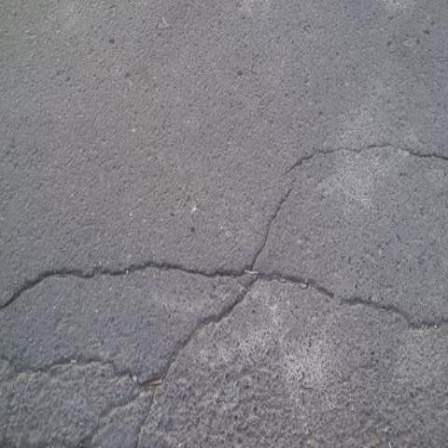

In [39]:
# Showing an individual image from the dataset
data = BytesIO(unprocessed_dataset[0]['bytes'])
im = Image.open(data)
display(im)

In [44]:
# Example of single image conversion to numpy array
array = np.array(im)
array.shape

(448, 448, 3)

In [48]:
# Converting entire dataset to numpy array
dataset = np.empty_like(unprocessed_dataset)
for i in range(len(unprocessed_dataset)):
    s_im = Image.open(BytesIO(unprocessed_dataset[i]['bytes']))
    dataset[i] = np.array(im)